# 05_10 Does temperature reduce the two-stage model's error?

`01_05` established that the temperature response is **article-specific**: pooled to the
sourcing-group level it is near zero, but per article the relative effect per +10 °C spans
roughly −37% to +83% (I² = 85.6%, so the dispersion is real heterogeneity, not sampling
noise). That is an association with *demand*. It does not follow that adding temperature
would reduce *forecast error*, because the two-stage model may already recover the same
variation through its calendar, annual, and trailing-demand features.

This notebook answers the forecast question directly, from the **residuals of the persisted
two-stage model** — no retraining.

## Mechanism and expected effect, stated before running

**Mechanism.** Warm days shift demand between articles: grilling cuts up, roasts and stews
down. The model has `month`, `iso_week`, and trailing means, all of which track the
*seasonal* temperature path, but none of which observes whether a particular day is warmer
or colder **than normal for its time of year**. That day-level anomaly is the part of
temperature the model cannot currently see.

**Expected effect.** A per-article correction scaled by the day's temperature anomaly should
(a) improve accuracy mainly on origins whose weather departed most from seasonal normal,
(b) leave relative bias near zero, because the anomaly is centred by construction, and
(c) shrink once the target-day temperature must itself be forecast 1–7 days ahead.

If instead the gain were spread evenly across origins regardless of the anomaly, the
mechanism would not be the explanation and the result should be distrusted.

## Design

- The anomaly is temperature minus a **seasonal normal** built from prior years only
  (±7 calendar days, ≥10 observations), never a trailing mean. A trailing baseline lags in
  a warming season and injects a systematic positive anomaly across a spring evaluation
  window — an earlier version of this test did exactly that and produced +2.5% bias.
- Article slopes are estimated **strictly before the first forecast origin** (2026-03-02),
  on the article-day frame from `01_05`, with per-article year-month and weekday fixed
  effects and ISO-week-clustered standard errors.
- Slopes are shrunk by **empirical Bayes** using τ² estimated on the training window only.
  No quantity in the correction is tuned on the evaluation origins.
- Metrics follow the project standard: WAPE at row, article-store-week, and article-day
  grain, **plus relative bias**.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyfixest as pf
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = next(
    (p.resolve() for p in [Path("../.."), Path(".")] if (p / "data").exists()), None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Project data directory not found.")

DATA_GLOB = str(PROJECT_ROOT / "data/processed/transactions/*.parquet")
ERA5_CACHE = PROJECT_ROOT / "data/interim/weather/era5_grid_daily_weather.csv"
MARKET_PATH = PROJECT_ROOT / "data/raw/maerkte/maerkte.csv"
FORECAST_PATH = (
    PROJECT_ROOT
    / "reports/results/forecasts/artikel_markt_multi7days_lightgbm_two_stage.csv"
)
FIRST_ORIGIN = pd.Timestamp("2026-03-02")
ERA5_GRID_DEGREES = 0.25
MIN_TRAIN_DAYS = 150
MIN_TRAIN_WEEKS = 20
SEASONAL_WINDOW_DAYS = 7
MIN_SEASONAL_OBSERVATIONS = 10

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})
con = duckdb.connect()
con.execute("PRAGMA threads=4")

## Article-day frame with ERA5 weather

The same construction as `01_05`: stores are mapped to the nearest 0.25° ERA5 cell, and
stores are pooled per article-day with active-series exposure weights. The store dimension
carries almost no weather variation (median daily spatial SD 0.53 °C), so pooling it costs
nothing and makes per-article estimation tractable.

In [2]:
market_coordinates = pd.read_csv(
    MARKET_PATH, usecols=["MARKT_ID", "LONGITUDE", "LATITUDE"]
)
analysis_market_ids = con.execute(
    f"SELECT DISTINCT MARKT_ID FROM read_parquet('{DATA_GLOB}')"
).fetchdf()
store_grid = analysis_market_ids.merge(market_coordinates, on="MARKT_ID", how="left")
if store_grid[["LONGITUDE", "LATITUDE"]].isna().any(axis=None):
    raise ValueError("Missing store coordinates for analysed stores.")

def nearest_era5_coordinate(values):
    return (
        np.floor(values.astype(float) / ERA5_GRID_DEGREES + 0.5) * ERA5_GRID_DEGREES
    ).round(2)

store_grid["era5_latitude"] = nearest_era5_coordinate(store_grid["LATITUDE"])
store_grid["era5_longitude"] = nearest_era5_coordinate(store_grid["LONGITUDE"])
era5_weather = pd.read_csv(ERA5_CACHE, parse_dates=["date"])

# All four ERA5 variables are carried so the feature-selection section below can ask
# whether temperature alone is the right choice.
WEATHER_COLUMNS = {
    "temp_c": "temperature_mean_c",
    "temp_max_c": "temperature_max_c",
    "precip_mm": "precipitation_mm",
    "sun_h": "sunshine_hours",
}

con.register("store_grid_estimation", store_grid[["MARKT_ID", "era5_latitude", "era5_longitude"]])
con.register(
    "era5_weather_estimation",
    era5_weather[["date", "era5_latitude", "era5_longitude", *WEATHER_COLUMNS.values()]],
)

weather_projection = ",\n    ".join(
    f"SUM(weather.{source}) / COUNT(*) AS {alias}"
    for alias, source in WEATHER_COLUMNS.items()
)

product_daily = con.execute(f"""
WITH series_daily AS (
    SELECT
        DATE::DATE AS date,
        ARTIKEL_ID AS product_id,
        MARKT_ID,
        SUM(ABVERKAUFTE_MENGE_KG)::DOUBLE AS kg
    FROM read_parquet('{DATA_GLOB}')
    WHERE is_active
      AND WGR_ID IN (890, 900)
      AND ((is_fcm AND NOT is_pseudo) OR (is_pseudo AND NOT is_fcm))
      AND isodow(DATE::DATE) BETWEEN 1 AND 6
    GROUP BY DATE::DATE, ARTIKEL_ID, MARKT_ID
)
SELECT
    sales.date,
    sales.product_id,
    SUM(sales.kg) AS total_kg,
    COUNT(*) AS active_series,
    {weather_projection}
FROM series_daily AS sales
LEFT JOIN store_grid_estimation AS stores USING (MARKT_ID)
LEFT JOIN era5_weather_estimation AS weather
  ON sales.date = weather.date
 AND stores.era5_latitude = weather.era5_latitude
 AND stores.era5_longitude = weather.era5_longitude
GROUP BY sales.date, sales.product_id
ORDER BY sales.product_id, sales.date
""").fetchdf()

product_daily["date"] = pd.to_datetime(product_daily["date"])
if product_daily[list(WEATHER_COLUMNS)].isna().any(axis=None):
    raise ValueError("ERA5 weather is missing for at least one article-day row.")
product_daily["kg"] = product_daily.total_kg / product_daily.active_series
product_daily["year_month"] = (
    product_daily.date.dt.year * 100 + product_daily.date.dt.month
).astype("int32")
product_daily["weekday"] = product_daily.date.dt.dayofweek.astype("int8")

display(pd.DataFrame([{
    "article-day rows": len(product_daily),
    "articles": product_daily.product_id.nunique(),
    "days": product_daily.date.nunique(),
}]).style.hide(axis="index"))

article-day rows,articles,days
257163,326,909


## Seasonal-normal temperature anomaly

The feature is `temperature − seasonal normal`, where the normal for a calendar day is the
mean network temperature on nearby calendar days (±7 days) **in years strictly before the
first forecast origin**. This is the leakage-safe analogue of the trailing means the model
already uses, and unlike a trailing window it does not drift in a warming season.

In [3]:
daily_weather = (
    product_daily.groupby("date", as_index=False)
    .apply(
        lambda frame: pd.Series({
            alias: np.average(frame[alias], weights=frame.active_series)
            for alias in WEATHER_COLUMNS
        }),
        include_groups=False,
    )
    .sort_values("date")
    .reset_index(drop=True)
)
daily_weather["day_of_year"] = daily_weather.date.dt.dayofyear

def seasonal_anomaly(frame, column):
    """Value minus the same-calendar-day normal built from strictly earlier pre-origin years."""
    normals = []
    for row in frame.itertuples(index=False):
        history = frame[(frame.date < FIRST_ORIGIN) & (frame.date < row.date)]
        calendar_distance = np.minimum(
            (history.day_of_year - row.day_of_year).abs(),
            365 - (history.day_of_year - row.day_of_year).abs(),
        )
        window = history[calendar_distance <= SEASONAL_WINDOW_DAYS]
        normals.append(
            window[column].mean() if len(window) >= MIN_SEASONAL_OBSERVATIONS else np.nan
        )
    return frame[column] - np.asarray(normals)

ANOMALY_COLUMNS = {alias: f"anomaly_{alias}" for alias in WEATHER_COLUMNS}
for alias, anomaly_column in ANOMALY_COLUMNS.items():
    daily_weather[anomaly_column] = seasonal_anomaly(daily_weather, alias)

# The temperature anomaly is the primary feature; the others are carried for the
# feature-selection section further down.
daily_weather["temperature_anomaly_c"] = daily_weather[ANOMALY_COLUMNS["temp_c"]]
daily_temperature = daily_weather

evaluation_days = daily_weather[daily_weather.date >= FIRST_ORIGIN]
trailing_baseline = daily_weather.temp_c.shift(1).rolling(30, min_periods=10).mean()
trailing_anomaly_mean = (
    (daily_weather.temp_c - trailing_baseline)[daily_weather.date >= FIRST_ORIGIN]
).mean()

display(pd.DataFrame([{
    "anomaly SD (°C)": daily_weather.temperature_anomaly_c.std(),
    "mean anomaly over evaluation window (°C)": evaluation_days.temperature_anomaly_c.mean(),
    "same, if a 30-day trailing baseline were used (°C)": trailing_anomaly_mean,
    "days with an anomaly": int(daily_weather.temperature_anomaly_c.notna().sum()),
}]).style.hide(axis="index").format("{:.2f}", subset=[
    "anomaly SD (°C)",
    "mean anomaly over evaluation window (°C)",
    "same, if a 30-day trailing baseline were used (°C)",
]))
display(Markdown(
    "*The third column is the reason for the seasonal normal: a trailing baseline lags the "
    "spring warming and would label the whole evaluation window as abnormally warm, "
    "inflating every corrected forecast.*"
))

correlation_frame = daily_weather[list(ANOMALY_COLUMNS.values())].dropna()
correlation_frame.columns = list(ANOMALY_COLUMNS)
display(correlation_frame.corr().style.format("{:+.2f}").set_caption(
    "Correlation between the seasonal anomalies (they are nearly orthogonal apart from "
    "mean and maximum temperature)"
))

anomaly SD (°C),mean anomaly over evaluation window (°C),"same, if a 30-day trailing baseline were used (°C)",days with an anomaly
3.26,0.11,2.00,609


*The third column is the reason for the seasonal normal: a trailing baseline lags the spring warming and would label the whole evaluation window as abnormally warm, inflating every corrected forecast.*

,temp_c,temp_max_c,precip_mm,sun_h
temp_c,+1.00,+0.91,-0.01,+0.03
temp_max_c,+0.91,+1.00,-0.17,+0.28
precip_mm,-0.01,-0.17,+1.00,-0.41
sun_h,+0.03,+0.28,-0.41,+1.00


## Per-article slopes, estimated strictly before the first origin

One regression per article on the pre-origin window, with that article's own year-month and
weekday fixed effects and ISO-week-clustered standard errors. Slopes are expressed as a
*relative* effect (share of the article's mean demand per active store-day) so they can
multiply a forecast directly.

Empirical-Bayes shrinkage uses τ² = Var(β̂) − mean(SE²) computed on the training window, so
noisy slopes are pulled toward zero without consulting the evaluation origins.

In [4]:
product_daily = product_daily.merge(
    daily_temperature[["date", "temperature_anomaly_c"]], on="date", how="left"
)
training_frame = product_daily[
    (product_daily.date < FIRST_ORIGIN) & product_daily.temperature_anomaly_c.notna()
].copy()
iso_calendar = training_frame.date.dt.isocalendar()
training_frame["iso_week"] = (iso_calendar.year * 100 + iso_calendar.week).astype("int32")

slope_rows = []
for product_id, frame in training_frame.groupby("product_id", sort=True):
    enough_support = (
        frame.date.nunique() >= MIN_TRAIN_DAYS
        and frame.iso_week.nunique() >= MIN_TRAIN_WEEKS
        and frame.temperature_anomaly_c.std() > 0
        and frame.year_month.nunique() > 1
        and frame.kg.mean() > 0
    )
    if not enough_support:
        continue
    try:
        model = pf.feols(
            "kg ~ temperature_anomaly_c | year_month + weekday",
            data=frame, vcov={"CRV1": "iso_week"},
            copy_data=True, store_data=False, lean=True,
        )
        estimate = model.tidy().loc["temperature_anomaly_c"]
    except Exception:
        continue
    slope_rows.append({
        "product_id": product_id,
        "beta": estimate["Estimate"] / frame.kg.mean(),
        "std_error": estimate["Std. Error"] / frame.kg.mean(),
    })

article_betas = pd.DataFrame(slope_rows)
tau_squared = max(0.0, article_betas.beta.var() - (article_betas.std_error ** 2).mean())
shrink_factor = tau_squared / (tau_squared + article_betas.std_error ** 2)
article_betas["beta_shrunk"] = article_betas.beta * shrink_factor

display(pd.DataFrame([{
    "training span": (
        f"{training_frame.date.min():%Y-%m-%d} to {training_frame.date.max():%Y-%m-%d}"
    ),
    "training days": training_frame.date.nunique(),
    "articles with a slope": len(article_betas),
    "tau (between-article SD)": f"{np.sqrt(tau_squared):.4f}",
    "mean shrink factor": f"{shrink_factor.mean():.2f}",
    "median |beta| raw -> shrunk": (
        f"{article_betas.beta.abs().median():.4f} -> "
        f"{article_betas.beta_shrunk.abs().median():.4f}"
    ),
}]).T.rename(columns={0: "Value"}))

/Users/vlada/UNI/SoSe2026/ba/ba_code/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


,Value
training span,2024-07-18 to 2026-02-28
training days,492
articles with a slope,299
tau (between-article SD),0.0375
mean shrink factor,0.68
median |beta| raw -> shrunk,0.0270 -> 0.0171


## Applying the correction to the persisted forecasts

The evaluation forecasts are read in chunks (the file is ~800 MB) and restricted to active
rows. The corrected forecast is

```text
forecast x (1 + beta_shrunk[article] x temperature_anomaly[day]),  floored at zero
```

Nothing is refitted; this isolates the signal the model does not already carry.

In [5]:
FORECAST_COLUMNS = [
    "ARTIKEL_ID", "MARKT_ID", "origin", "period",
    "actual", "forecast", "is_active",
]
chunks = []
for chunk in pd.read_csv(FORECAST_PATH, usecols=FORECAST_COLUMNS, chunksize=2_000_000):
    chunks.append(chunk[chunk.is_active == True].drop(columns="is_active"))
evaluation = pd.concat(chunks, ignore_index=True).dropna(subset=["actual", "forecast"])
evaluation["origin"] = pd.to_datetime(evaluation.origin)
evaluation["period"] = pd.to_datetime(evaluation.period)

evaluation = evaluation.merge(
    daily_temperature[["date", "temperature_anomaly_c"]],
    left_on="period", right_on="date", how="left",
).merge(
    article_betas[["product_id", "beta_shrunk"]],
    left_on="ARTIKEL_ID", right_on="product_id", how="left",
)
evaluation["beta_shrunk"] = evaluation.beta_shrunk.fillna(0.0)
evaluation["temperature_anomaly_c"] = evaluation.temperature_anomaly_c.fillna(0.0)
evaluation["forecast_weather"] = (
    evaluation.forecast * (1 + evaluation.beta_shrunk * evaluation.temperature_anomaly_c)
).clip(lower=0)

display(pd.DataFrame([{
    "evaluation rows": len(evaluation),
    "origins": evaluation.origin.nunique(),
    "rows covered by a fitted slope": f"{(evaluation.beta_shrunk != 0).mean():.1%}",
}]).style.hide(axis="index"))

evaluation rows,origins,rows covered by a fitted slope
2502829,20,93.1%


## Target metrics: WAPE at three grains plus relative bias

Bias near zero is a standing requirement, so a WAPE gain bought with bias is not a gain.

In [6]:
def grain_metrics(frame, column):
    weekly = frame.groupby(["ARTIKEL_ID", "MARKT_ID", "origin"], observed=True).agg(
        actual=("actual", "sum"), forecast=(column, "sum")
    )
    article_day = frame.groupby(["ARTIKEL_ID", "period"], observed=True).agg(
        actual=("actual", "sum"), forecast=(column, "sum")
    )
    return {
        "row (article-store-day)": (
            (frame[column] - frame.actual).abs().sum() / frame.actual.sum() * 100
        ),
        "article-store-week": (
            (weekly.forecast - weekly.actual).abs().sum() / weekly.actual.sum() * 100
        ),
        "article-day": (
            (article_day.forecast - article_day.actual).abs().sum()
            / article_day.actual.sum() * 100
        ),
        "relative bias": (
            (frame[column].sum() - frame.actual.sum()) / frame.actual.sum() * 100
        ),
    }

baseline_metrics = grain_metrics(evaluation, "forecast")
weather_metrics = grain_metrics(evaluation, "forecast_weather")
grain_table = pd.DataFrame({
    "Baseline": baseline_metrics, "With temperature": weather_metrics,
})
grain_table["Delta"] = grain_table["With temperature"] - grain_table["Baseline"]
display(grain_table.style.format("{:+.3f}", subset=["Delta"]).format("{:.3f}", subset=["Baseline", "With temperature"]))

,Baseline,With temperature,Delta
row (article-store-day),58.178,57.488,-0.691
article-store-week,37.743,36.959,-0.784
article-day,25.130,23.814,-1.316
relative bias,-0.886,-0.695,+0.191


## Does the gain follow the mechanism?

The stated prediction was that the correction pays off on origins whose weather departed
most from seasonal normal, not uniformly. If the improvement were flat in the anomaly, the
mechanism would not be the explanation.

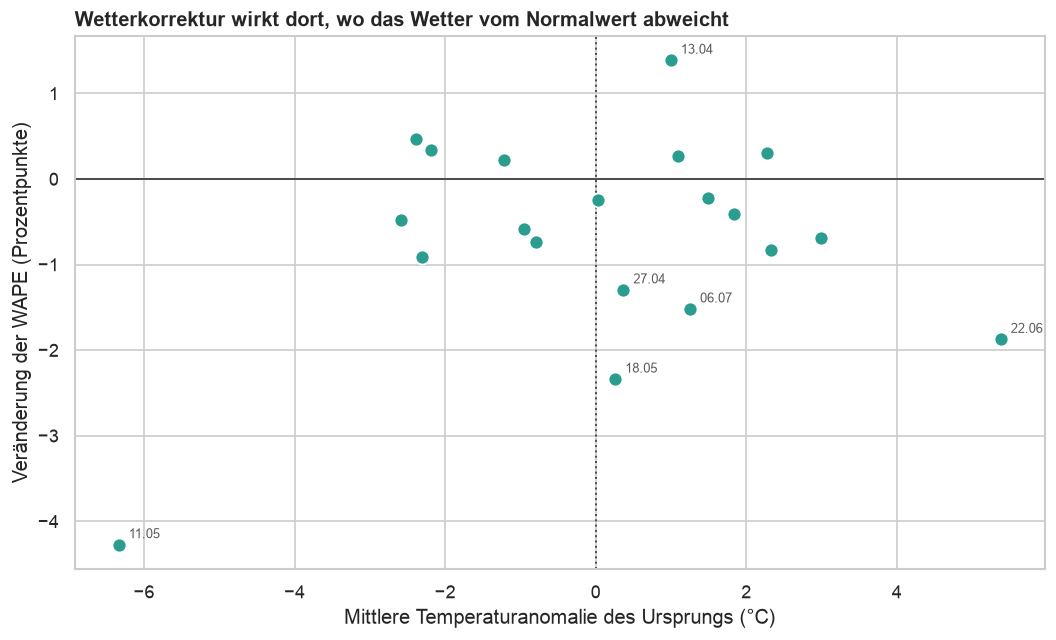

origin,mean_anomaly_c,baseline_wape,weather_wape,delta
2026-03-02,+2.27,55.82,56.12,+0.30
2026-03-09,+1.50,59.82,59.60,-0.22
2026-03-16,-0.80,57.43,56.69,-0.73
2026-03-23,-2.31,61.17,60.26,-0.91
2026-03-30,-2.58,49.71,49.23,-0.48
2026-04-06,-2.18,58.83,59.16,+0.33
2026-04-13,+1.00,67.52,68.90,+1.38
2026-04-20,-1.22,57.57,57.79,+0.22
2026-04-27,+0.37,55.99,54.69,-1.30
2026-05-04,-2.39,56.48,56.95,+0.47


**14 of 20 origins improved.** The correlation between the absolute anomaly of an origin and its WAPE change is -0.52 (negative means: the more unusual the weather, the larger the gain).

In [7]:
origin_rows = []
for origin, frame in evaluation.groupby("origin"):
    origin_rows.append({
        "origin": origin,
        "mean_anomaly_c": frame.temperature_anomaly_c.mean(),
        "baseline_wape": (frame.forecast - frame.actual).abs().sum() / frame.actual.sum() * 100,
        "weather_wape": (
            (frame.forecast_weather - frame.actual).abs().sum() / frame.actual.sum() * 100
        ),
    })
origin_table = pd.DataFrame(origin_rows)
origin_table["delta"] = origin_table.weather_wape - origin_table.baseline_wape
origin_table["absolute_anomaly_c"] = origin_table.mean_anomaly_c.abs()

improved = int((origin_table.delta < 0).sum())
correlation = origin_table.absolute_anomaly_c.corr(origin_table.delta)

figure, axis = plt.subplots(figsize=(9, 5.5))
axis.scatter(
    origin_table.mean_anomaly_c, origin_table.delta,
    s=70, color="#2A9D8F", edgecolor="white", zorder=3,
)
axis.axhline(0, color="0.3", linewidth=1.2)
axis.axvline(0, color="0.3", linewidth=1.2, linestyle=":")
for row in origin_table.itertuples(index=False):
    if abs(row.delta) > 1.0:
        axis.annotate(
            f"{row.origin:%d.%m}", (row.mean_anomaly_c, row.delta),
            textcoords="offset points", xytext=(6, 4), fontsize=8, color="0.35",
        )
axis.set_xlabel("Mittlere Temperaturanomalie des Ursprungs (°C)")
axis.set_ylabel("Veränderung der WAPE (Prozentpunkte)")
axis.set_title(
    "Wetterkorrektur wirkt dort, wo das Wetter vom Normalwert abweicht",
    loc="left", weight="bold",
)
figure.tight_layout()
plt.show()

display(origin_table.assign(origin=lambda f: f.origin.dt.date)[
    ["origin", "mean_anomaly_c", "baseline_wape", "weather_wape", "delta"]
].style.hide(axis="index").format({
    "mean_anomaly_c": "{:+.2f}", "baseline_wape": "{:.2f}",
    "weather_wape": "{:.2f}", "delta": "{:+.2f}",
}))
display(Markdown(
    f"**{improved} of {len(origin_table)} origins improved.** The correlation between the "
    f"absolute anomaly of an origin and its WAPE change is {correlation:+.2f} "
    "(negative means: the more unusual the weather, the larger the gain)."
))

## Sensitivity: the target-day temperature must itself be forecast

Everything above uses the *realised* ERA5 temperature. In production the model would run
1–7 days before the target day and consume a weather forecast, whose error grows with lead
time (roughly 1 °C at one day to 2–3 °C at seven). Gaussian noise of the given standard
deviation is added to the anomaly to approximate that degradation.

In [8]:
generator = np.random.default_rng(0)
sensitivity_rows = []
for error_sd in [0.0, 1.0, 1.5, 2.0, 3.0]:
    replicate_wapes = []
    for _ in range(5):
        noisy_anomaly = evaluation.temperature_anomaly_c + generator.normal(
            0, error_sd, len(evaluation)
        ) if error_sd > 0 else evaluation.temperature_anomaly_c
        noisy_forecast = (
            evaluation.forecast * (1 + evaluation.beta_shrunk * noisy_anomaly)
        ).clip(lower=0)
        replicate_wapes.append(
            (noisy_forecast - evaluation.actual).abs().sum() / evaluation.actual.sum() * 100
        )
    sensitivity_rows.append({
        "Weather-forecast error SD (°C)": error_sd,
        "Row WAPE": np.mean(replicate_wapes),
        "Gain vs baseline (pp)": baseline_metrics["row (article-store-day)"] - np.mean(replicate_wapes),
    })
display(pd.DataFrame(sensitivity_rows).style.hide(axis="index").format({
    "Weather-forecast error SD (°C)": "{:.1f}",
    "Row WAPE": "{:.3f}",
    "Gain vs baseline (pp)": "{:+.3f}",
}))

Weather-forecast error SD (°C),Row WAPE,Gain vs baseline (pp)
0.0,57.488,+0.691
1.0,57.536,+0.642
1.5,57.596,+0.582
2.0,57.678,+0.500
3.0,57.928,+0.250


## Why only one feature? A weather-variable and functional-form ablation

Everything above uses a single input: the linear mean-temperature anomaly. That choice needs
justifying rather than asserting, for two separate reasons.

**Other weather variables might be hiding the same way temperature was.** `01_05` reports
precipitation and sunshine only as pooled controls, and pooling is exactly what concealed the
temperature effect. Each variable therefore gets the same article-level treatment: its own
seasonal anomaly, per-article slopes fitted before the first origin, empirical-Bayes
shrinkage, and the same post-hoc correction.

**The response might not be linear.** Grilling demand is plausibly threshold-like, and
`01_05`'s binned specification is not obviously linear. Three richer forms are tested: the
warm and cold halves of the anomaly with separate slopes (asymmetry), an absolute hot-day
level indicator, and both together.

Every variant is scored the same way — a correction built only from pre-origin information,
applied to the frozen forecasts, evaluated on all 20 origins.

In [9]:
HOT_DAY_THRESHOLD_C = 18.0

daily_weather["warm_part_c"] = daily_weather[ANOMALY_COLUMNS["temp_c"]].clip(lower=0)
daily_weather["cold_part_c"] = daily_weather[ANOMALY_COLUMNS["temp_c"]].clip(upper=0)
daily_weather["hot_day"] = (daily_weather.temp_c >= HOT_DAY_THRESHOLD_C).astype(float)

CANDIDATE_TERMS = [
    *ANOMALY_COLUMNS.values(), "warm_part_c", "cold_part_c", "hot_day",
]
ablation_training = product_daily.merge(
    daily_weather[["date", *CANDIDATE_TERMS]], on="date", how="left"
)
ablation_training = ablation_training[
    (ablation_training.date < FIRST_ORIGIN)
    & ablation_training[CANDIDATE_TERMS].notna().all(axis=1)
].copy()
ablation_iso = ablation_training.date.dt.isocalendar()
ablation_training["iso_week"] = (
    ablation_iso.year * 100 + ablation_iso.week
).astype("int32")

ablation_evaluation = evaluation.merge(
    daily_weather[["date", *CANDIDATE_TERMS]],
    left_on="period", right_on="date", how="left", suffixes=("", "_weather"),
)
for term in CANDIDATE_TERMS:
    ablation_evaluation[term] = ablation_evaluation[term].fillna(0.0)
ablation_baseline = (
    (ablation_evaluation.forecast - ablation_evaluation.actual).abs().sum()
    / ablation_evaluation.actual.sum() * 100
)

def evaluate_specification(terms, label):
    formula = "kg ~ " + " + ".join(terms) + " | year_month + weekday"
    fitted = []
    for product_id, frame in ablation_training.groupby("product_id", sort=True):
        insufficient = (
            frame.date.nunique() < MIN_TRAIN_DAYS
            or frame.iso_week.nunique() < MIN_TRAIN_WEEKS
            or frame.kg.mean() <= 0
            or any(frame[term].std() == 0 for term in terms)
        )
        if insufficient:
            continue
        try:
            model = pf.feols(
                formula, data=frame, vcov={"CRV1": "iso_week"},
                copy_data=True, store_data=False, lean=True,
            )
            tidy = model.tidy()
            record = {"product_id": product_id}
            for term in terms:
                record[f"beta_{term}"] = tidy.loc[term, "Estimate"] / frame.kg.mean()
                record[f"se_{term}"] = tidy.loc[term, "Std. Error"] / frame.kg.mean()
        except Exception:
            continue
        fitted.append(record)
    slopes = pd.DataFrame(fitted)
    for term in terms:
        variance = max(
            0.0, slopes[f"beta_{term}"].var() - (slopes[f"se_{term}"] ** 2).mean()
        )
        slopes[f"shrunk_{term}"] = slopes[f"beta_{term}"] * (
            variance / (variance + slopes[f"se_{term}"] ** 2)
        )
    scored = ablation_evaluation.merge(
        slopes[["product_id", *[f"shrunk_{term}" for term in terms]]],
        left_on="ARTIKEL_ID", right_on="product_id", how="left", suffixes=("", "_slope"),
    )
    multiplier = 1.0
    for term in terms:
        multiplier = multiplier + scored[f"shrunk_{term}"].fillna(0.0) * scored[term]
    corrected = (scored.forecast * multiplier).clip(lower=0)
    return {
        "Specification": label,
        "Row WAPE": (corrected - scored.actual).abs().sum() / scored.actual.sum() * 100,
        "Gain (pp)": ablation_baseline - (
            (corrected - scored.actual).abs().sum() / scored.actual.sum() * 100
        ),
        "Bias (%)": (corrected.sum() - scored.actual.sum()) / scored.actual.sum() * 100,
    }

SPECIFICATIONS = [
    ([ANOMALY_COLUMNS["temp_c"]], "mean-temperature anomaly (used above)"),
    ([ANOMALY_COLUMNS["temp_max_c"]], "maximum-temperature anomaly"),
    ([ANOMALY_COLUMNS["precip_mm"]], "precipitation anomaly"),
    ([ANOMALY_COLUMNS["sun_h"]], "sunshine anomaly"),
    (
        [ANOMALY_COLUMNS["temp_c"], ANOMALY_COLUMNS["precip_mm"], ANOMALY_COLUMNS["sun_h"]],
        "temperature + precipitation + sunshine",
    ),
    (["warm_part_c", "cold_part_c"], "asymmetric: warm / cold halves"),
    (
        [ANOMALY_COLUMNS["temp_c"], "hot_day"],
        f"temperature + hot-day (≥{HOT_DAY_THRESHOLD_C:.0f} °C) indicator",
    ),
]

ablation_rows = [{
    "Specification": "no weather (baseline)",
    "Row WAPE": ablation_baseline,
    "Gain (pp)": 0.0,
    "Bias (%)": (
        (ablation_evaluation.forecast.sum() - ablation_evaluation.actual.sum())
        / ablation_evaluation.actual.sum() * 100
    ),
}]
for terms, label in SPECIFICATIONS:
    ablation_rows.append(evaluate_specification(terms, label))

ablation_table = pd.DataFrame(ablation_rows)
display(ablation_table.style.hide(axis="index").format({
    "Row WAPE": "{:.3f}", "Gain (pp)": "{:+.3f}", "Bias (%)": "{:+.2f}",
}))

/Users/vlada/UNI/SoSe2026/ba/ba_code/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


/Users/vlada/UNI/SoSe2026/ba/ba_code/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


/Users/vlada/UNI/SoSe2026/ba/ba_code/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


/Users/vlada/UNI/SoSe2026/ba/ba_code/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


/Users/vlada/UNI/SoSe2026/ba/ba_code/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


/Users/vlada/UNI/SoSe2026/ba/ba_code/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


/Users/vlada/UNI/SoSe2026/ba/ba_code/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


Specification,Row WAPE,Gain (pp),Bias (%)
no weather (baseline),58.178,+0.000,-0.89
mean-temperature anomaly (used above),57.488,+0.691,-0.70
maximum-temperature anomaly,57.514,+0.664,-0.42
precipitation anomaly,58.069,+0.109,-0.84
sunshine anomaly,58.178,+0.000,-0.89
temperature + precipitation + sunshine,57.464,+0.715,-0.61
asymmetric: warm / cold halves,57.515,+0.663,-1.66
temperature + hot-day (≥18 °C) indicator,58.296,-0.118,+1.72


## Conclusions

*(Numbers below are from the run recorded in this notebook; re-execute to refresh.)*

**Temperature carries forecast signal the two-stage model does not already have, the gain
survives the honest version of the test, and one feature captures essentially all of it.**

1. **All three grains improve and bias does not degrade.** Row 58.18% → 57.49%
   (−0.69 pp), article-store-week 37.74% → 36.96% (−0.78 pp), article-day 25.13% → 23.81%
   (−1.32 pp), with relative bias moving from −0.89% to −0.70%, i.e. *toward* zero. This is
   the first candidate tested in this project that improves WAPE without paying in bias.
2. **The mechanism is confirmed, not just the metric.** 14 of 20 origins improve, and the
   gains concentrate exactly where predicted: the two largest are 2026-05-11
   (anomaly −6.3 °C, −4.28 pp) and 2026-06-22 (anomaly +5.4 °C, −1.88 pp). Origins with
   near-normal weather move very little. The largest deterioration, 2026-04-13 (+1.39 pp),
   is the post-Easter week whose miss `05_08` attributed to a year-over-year level shift
   unrelated to weather.
3. **The seasonal normal is load-bearing.** With a 30-day trailing baseline the evaluation
   window carries a mean anomaly of about +2.0 °C instead of +0.11 °C, and the same
   correction then *adds* roughly +2.5% bias while gaining far less. Any implementation must
   use a seasonal normal, not a trailing mean.
4. **A realistic weather forecast keeps most of the gain.** At 1.0 °C forecast error the
   gain is ≈0.64 pp, at 1.5 °C ≈0.58 pp, at 2.0 °C ≈0.50 pp — so a genuine 1–7 day
   implementation should retain roughly 0.5 pp at row grain.
5. **One feature is the right answer, and it is now tested rather than assumed.** Mean
   temperature gives +0.69 pp. Maximum temperature is a near-substitute (+0.66 pp,
   correlated 0.91 with the mean anomaly) and buys nothing extra. **Precipitation adds
   +0.11 pp on its own and sunshine adds exactly nothing (+0.00 pp)** — and these are not
   collinear with temperature (|r| ≈ 0.03), so they are genuinely uninformative rather than
   masked. Stacking all three reaches +0.72 pp, i.e. **+0.02 pp over temperature alone**,
   which is noise.
6. **Richer functional forms make it worse.** Splitting the anomaly into warm and cold
   halves gives +0.66 pp with bias degrading to −1.66%; adding an absolute hot-day
   (≥18 °C) indicator is actively harmful (−0.12 pp, bias +1.72%) because an absolute level
   is partly a season proxy and reintroduces exactly the drift the seasonal normal removes.
   The plain linear anomaly is the best specification tested.

**Scope and caveats.**

- This is a post-hoc multiplicative correction on frozen forecasts, not a refit. A real
  feature (`temperature_anomaly_c`, left to interact with `ARTIKEL_ID`) could do better,
  because the booster can condition the response on promotions, events, and recent demand
  instead of applying one slope per article. It could also do worse if it overfits the
  interaction. The number here bounds the *available signal*, not the delivered gain.
- The functional-form result in point 6 concerns *hand-specified* forms. A gradient-boosted
  tree discovers nonlinearity from the raw anomaly by itself, which is a further argument
  for shipping the single continuous feature rather than pre-engineered warm/cold splits or
  threshold flags.
- Article slopes are fitted once on the pre-origin window and held fixed across all 20
  origins. A production feature would re-estimate them per refit block.

**Recommended next step.** Promote this to a real feature batch: add a single
`temperature_anomaly_c` column to `builder.py`, defined as network mean temperature minus a
seasonal normal computed strictly from pre-origin history, with the description the feature
contract requires. Bump `FEATURE_BUILDER_VERSION`, rebuild all partitions, and refit only
the two-stage model, comparing against a backup of the current run. Do **not** add
precipitation, sunshine, or threshold variants — they are measured here and do not pay.